In [20]:
import torch
import torch.nn as nn
import numpy as np

if torch.cuda.is_available():
    print("CUDA is available!")
    DEVICE = torch.device("cuda")
else:
    print("CUDA is not available!")
    DEVICE = torch.device("cpu")

# sensible constants
LABELS = 12
LENGTH = 128
FEATURES = 6

REAL_LABEL = 1
FAKE_LABEL = 0

CUDA is available!


## Define loss functions

In [21]:
import numpy as np

# introduce machine epsilon to prevent log from reaching NaN
EPS = 1e-9

# least squares discriminator loss - may be more stable
def leastsquares_d_loss(classification_real, classification_fake):
    return torch.mean( (classification_real - REAL_LABEL)**2 ) / 2.0 + torch.mean( (classification_fake - FAKE_LABEL)**2 ) / 2.0

# least squares generator loss - may be more stable
def leastsquares_g_loss(classification_fake):
    return torch.mean( (classification_fake - REAL_LABEL)**2 ) / 2.0

# taken from the GAN paper, essentially nn.BCELoss()
def bce_d_loss(classification_real, classification_fake):
    
    return -(
        torch.mean(torch.log(classification_real + EPS))
        + torch.mean(torch.log(1 - classification_fake + EPS))
    )

# taken from the GAN paper, essentially nn.BCELoss()
def bce_g_loss(classification_fake):
    return -torch.mean(torch.log(classification_fake + EPS))

compute_discriminator_loss = bce_d_loss
compute_generator_loss = bce_g_loss

In [22]:
import matplotlib.pyplot as plt
import IPython
from utils import show_dataset

In [23]:
def train(
    generator: nn.Module,
    discriminator: nn.Module,
    train_dataloader,
    g_optimizer,
    d_optimizer,
    epochs,
    n_discriminator=3,
    show_output=0,
):
    """
    Training loop for GANs

    with inspiration from https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
    additionally added:
     - epoch evaluation every 10 epoch by generating a sequence from a given label `show_output`
     - loss tracking and return
     - multiple discriminator optimizer steps adjustable by `n_discriminator`
    """
    generator = generator.to(DEVICE)
    discriminator = discriminator.to(DEVICE)

    log_loss_d = []
    log_loss_g = []

    for epoch in range(epochs):
        if epoch % 10 == 0:
            generator.eval()
            discriminator.eval()
            artificial = generator(generator.sample(1, device=DEVICE), torch.tensor(np.array([show_output]), device=DEVICE) )
            IPython.display.clear_output(wait=True)
            fig = show_dataset(artificial.cpu().detach().numpy().squeeze())
            IPython.display.display(fig)
            plt.close(fig)
            
        for i, (data, labels) in enumerate(train_dataloader):
            generator.train()
            discriminator.train()
            batch_size = data.size(0)
            data = data.to(DEVICE)
            labels = labels.to(DEVICE)

            ### --- TRAIN DISCRIMINATOR --- ####
            for _ in range(n_discriminator):
                classification_real = discriminator(data, labels)

                noise = generator.sample(batch_size, device=DEVICE)
                with torch.no_grad():
                    gen_output = generator(noise, labels)  # no gradients for discriminator
                classification_fake = discriminator(gen_output, labels)

                discriminator_loss = compute_discriminator_loss(
                    classification_real, classification_fake
                )
                discriminator_loss.backward()
                d_optimizer.step()
                d_optimizer.zero_grad()

            ### --- TRAIN GENERATOR --- ###
            noise = generator.sample(batch_size, device=DEVICE)
            gen_output = generator(noise, labels)
            classification_fake = discriminator(gen_output, labels)

            generator_loss = compute_generator_loss(classification_fake)
            generator_loss.backward()
            g_optimizer.step()
            g_optimizer.zero_grad()

            ### LOGGING
            if i % 100 == 0:
                log_loss_d.append(discriminator_loss.item())
                log_loss_g.append(generator_loss.item())
                print(
                    "EPOCH %d @ %d : discriminator %.4f generator %.4f "
                    % (epoch+1, i, discriminator_loss.item(), generator_loss.item())
                )
        
    return log_loss_d, log_loss_g

In [24]:
import pickle as pkl
import os

DATASETS_PATH = os.path.join('..', '..', '..','data')

with open(os.path.join( DATASETS_PATH, 'train.pickle'), "rb") as f:
    train_dataset = pkl.load(f)

train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4053 entries, 0 to 4052
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sensor_data           4053 non-null   object 
 1   label                 4053 non-null   int64  
 2   model                 4053 non-null   object 
 3   velocity              4053 non-null   int64  
 4   mass                  4053 non-null   float64
 5   deceleration_average  4053 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 190.1+ KB


/tmp/ipykernel_32/1766516076.py:7: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  train_dataset = pkl.load(f)


In [25]:
train_data = torch.tensor(
    np.array(list(train_dataset["sensor_data"]), dtype=np.float32)
)

label_data = torch.tensor(
    np.array(list(train_dataset["label"]))
)

# normalization
print(train_data.shape)
print(label_data.shape)

torch.Size([4053, 128, 6])
torch.Size([4053])


In [26]:
from torch.utils.data import StackDataset, DataLoader

train_dataloader = DataLoader(StackDataset(train_data, label_data), batch_size=32)

In [27]:
from model import CNNGenerator, CNNDiscriminator

generator = CNNGenerator()
discriminator = CNNDiscriminator()

## Training 

- By default use 200 epochs. This should be more than enough for some useful data.
- The optimizer should be `Adam`, although sometimes papers use `SGD` for the discriminator.
- The learning rate can be adjusted but should be in the ballpark of 1e-4. 
  If the learning rate is too high, the generator and discriminator becomes unstable and in the worst case the generator does not learn anything.
  If the learning rate is too low, the discriminator may overpower the generator and we have vanishing gradients.

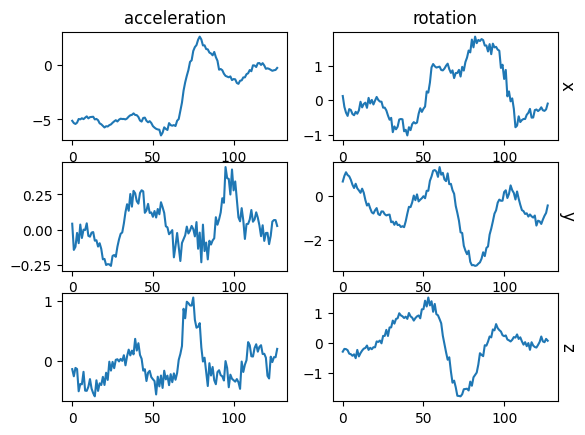

EPOCH 191 @ 0 : discriminator 0.4148 generator 1.2710 
EPOCH 191 @ 100 : discriminator 0.3297 generator 1.3389 
EPOCH 192 @ 0 : discriminator 0.4847 generator 1.1693 
EPOCH 192 @ 100 : discriminator 0.3728 generator 1.3223 
EPOCH 193 @ 0 : discriminator 0.5051 generator 1.0144 
EPOCH 193 @ 100 : discriminator 0.2850 generator 1.4251 
EPOCH 194 @ 0 : discriminator 0.4998 generator 1.1450 
EPOCH 194 @ 100 : discriminator 0.2847 generator 1.5489 
EPOCH 195 @ 0 : discriminator 0.3868 generator 1.2533 
EPOCH 195 @ 100 : discriminator 0.2579 generator 1.5281 
EPOCH 196 @ 0 : discriminator 1.0979 generator 1.0973 
EPOCH 196 @ 100 : discriminator 0.2658 generator 1.5114 
EPOCH 197 @ 0 : discriminator 0.3512 generator 1.3518 
EPOCH 197 @ 100 : discriminator 0.3588 generator 1.3666 
EPOCH 198 @ 0 : discriminator 0.3996 generator 1.2877 
EPOCH 198 @ 100 : discriminator 0.3079 generator 1.3617 
EPOCH 199 @ 0 : discriminator 0.3981 generator 1.3214 
EPOCH 199 @ 100 : discriminator 0.8895 generator 

In [28]:
generator_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4)
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

num_epochs=200

loss_d, loss_g = train(
    generator,
    discriminator,
    train_dataloader,
    generator_optimizer,
    discriminator_optimizer,
    num_epochs,
    n_discriminator=3,
    show_output=5
)

In [29]:
from utils import evaluate_discriminator

# show how the discriminator performs actually
evaluate_discriminator(generator, discriminator, train_dataloader, DEVICE)

(0.6581544280052185, (0.5067850947380066, 0.8095237612724304))

## Plot the discriminator and generator loss

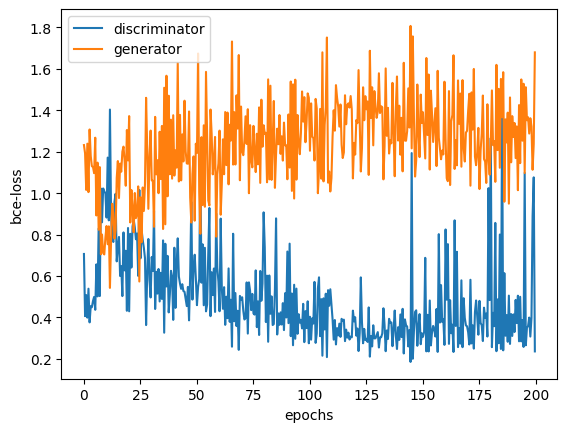

In [30]:
plt.plot(np.arange(num_epochs*2)/2, loss_d, label='discriminator')
plt.plot(np.arange(num_epochs*2)/2, loss_g, label='generator')
plt.ylabel('bce-loss')
plt.xlabel('epochs')
plt.legend()
# plt.savefig('loss_plot.png')

In [31]:
def generate_data(generator, num_datasets, device):
    """
    Generates `num_dataset` number of datasets for each label. 
    This is purely for looking at the distribution. 
    """
    generator.eval()
    generator.to(device)
    datasets = []
    for i in range(LABELS):
        datasets.append( generator( generator.sample(num_datasets,  device=device), i*torch.ones(num_datasets, dtype=torch.int, device=device) ) )
    # print(datasets)
    return torch.stack(datasets, axis=0).cpu().detach().numpy()

In [32]:
NUM_SAMPLES = 100

gen_data = generate_data(generator, NUM_SAMPLES, DEVICE)
print(gen_data.shape)

(12, 100, 128, 6)


## Look at the generated data

This may only work in the JupyterLab and not in VSCode. If you know some `ipywidgets` you may understand what `show` does.

In addition, I supplied a small helper which smoothes 1D-input and a checkbox (if you are in the browser) which enables and disables smoothing.

In [33]:
from ipywidgets import interact, IntSlider, Checkbox
from utils import show_dataset
import torch.nn.functional as F

def smooth1d(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth


FAILURE_CLASSES = [
    ("0-0-0-0", "All brakes intact (no irregularities)."),
    ("0-0-1-0", "Rear Left Brake with irregularity."),
    ("0-0-0-1", "Rear Right Brake with irregularity."),
    ("0-0-1-1", "Both Rear Brakes with irregularities."),
    ("1-0-0-0", "Front Left Brake with irregularity."),
    ("0-1-0-0", "Front Right Brake with irregularity."),
    ("1-1-0-0", "Both Front Brakes with irregularities."),
    ("1-0-1-0", "Left Brakes (Front + Rear Left) with irregularities."),
    ("0-1-0-1", "Right Brakes (Front + Rear Right) with irregularities."),
    ("1-0-0-1", "Front Left and Rear Right Brakes with irregularities."),
    ("0-1-1-0", "Front Right and Rear Left Brakes with irregularities."),
    ("1-1-1-1", "All Brakes with irregularities.")
]
print(gen_data.shape)

@interact(classification=IntSlider(min=0,max=11,step=1,value=0), sample=IntSlider(min=0,max=NUM_SAMPLES-1,step=1,value=0),  smooth=Checkbox(value=False, description='Smooth?') )
def show(classification, sample, smooth=False):
    selected_data = gen_data[classification,sample]
    if smooth:
        selected_data = np.apply_along_axis(smooth1d, -2, selected_data, box_pts=15)
    fig = show_dataset(selected_data)
    fig.suptitle("sampled curve - {}".format(FAILURE_CLASSES[classification][0]) )

(12, 100, 128, 6)


interactive(children=(IntSlider(value=0, description='classification', max=11), IntSlider(value=0, description…

## Evaluate the Generator output

Here we import the train dataset and compute the mean (per timestep, per feature) for every label. 

We then sample 1000 time series per label and compute their average least-squares distance to the mean curve.
The result is a rough estimate of the quality of our output data. 

In [34]:
from utils import generate_mean_by_class

TEST_DATASET_PATH = os.path.join(DATASETS_PATH, 'train.pickle')

# open test and train dataset with pickle - the resulting object is a pandas.DataFrame
with open(TEST_DATASET_PATH, 'rb') as f:
    test_dataset = pkl.load(f)

# generate mean by class
mean_by_class = generate_mean_by_class(test_dataset)
print(mean_by_class.shape)

def eval_generator(mean_by_class, generator, num_samples, device):
    # generate num_samples per class
    gen_data = generate_data(generator, num_samples, device=device)
    err_by_class = []
    
    for i in range(LABELS):
        class_data = gen_data[i] 
        err_ls = np.mean((mean_by_class[i] - gen_data[i])**2, axis=-2) # (num_samples, 6)
        err_ls = np.sum(err_ls, axis=-1) # (num_samples, )
        err_ls = np.mean(err_ls)
        err_by_class.append(err_ls)
    return np.array(err_by_class)

eval_generator(mean_by_class, generator, 1000, DEVICE)

/tmp/ipykernel_32/2575696248.py:7: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  test_dataset = pkl.load(f)


(12, 128, 6)


array([ 0.45843074,  1.025859  ,  0.7803492 ,  1.0157076 ,  1.0468335 ,
        3.4441402 ,  0.6286487 ,  1.1843562 , 17.69632   ,  4.7314687 ,
        1.3269103 ,  3.6089354 ], dtype=float32)

## Save the model

In [35]:
# save model to model directory
model_dir = os.path.join('..', 'models')
os.makedirs(model_dir, exist_ok=True)

torch.save(generator.state_dict(), os.path.join(model_dir,'generator-gan.pt') )